У вас есть три набора данных (рост матерей, рост отцов и рост детей соответственно), представленных в виде массивов numpy:

moms_height = np.array([162, 175, 163, 170, 175])
dads_height = np.array([173, 170, 175, 180, 185])
child_height = np.array([168, 172, 168, 181, 180])

In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Данные
moms_height = np.array([162, 175, 163, 170, 175])
dads_height = np.array([173, 170, 175, 180, 185])
child_height = np.array([168, 172, 168, 181, 180])

Задание 1.2. Объедините массивы с ростом матери и отца в одну матрицу признаков X. В качестве целевой переменной y используйте child_height.

In [3]:
# Подготовка данных для sklearn
X = np.column_stack((moms_height, dads_height))
y = child_height

# Для проверки выведите X на экран
print(X)

[[162 173]
 [175 170]
 [163 175]
 [170 180]
 [175 185]]


ЭТАП 2. Построение и обучение модели
Теперь, когда данные готовы, можно создать и обучить модель линейной регрессии. Создайте экземпляр модели LinearRegression и обучите ее на ваших данных X и y.

In [4]:
# Построение модели линейной регрессии
model = LinearRegression()
model.fit(X, y)

LinearRegression()

ЭТАП 3. Получение уровнения регрессии
Обученная модель содержит в себе коэффициенты регрессии и свободный член (intercept), которые составляют искомое уравнение.

Задание 3.1. Извлеките из модели коэффициенты (coefficients) и свободный член (intercept).

In [5]:
# Получение коэффициентов регрессии и свободного члена
coefficients = model.coef_
intercept = model.intercept_

Задание 3.2. Составьте и выведите на экран уравнение регрессии в формате: Child_Height = intercept + coef_1*Mom_Height + coef_2*Dad_Height. Округлите все числовые значения до двух знаков после запятой.

In [6]:
# Уравнение регрессии
equation = f"Child_Height = {intercept:.2f} + {coefficients[0]:.2f}*Mom_Height + {coefficients[1]:.2f}*Dad_Height"

# Вывод уравнения регрессии
print("Уравнение плоскости регрессии:")
print(equation)

Уравнение плоскости регрессии:
Child_Height = -26.36 + 0.48*Mom_Height + 0.67*Dad_Height


Задание 4. Предсказание на основе модели.

Главная задача модели — делать предсказания для новых данных. Используя обученную модель, предскажите рост ребенка, если рост его матери составляет 170 см, а рост отца — 175 см. Введите предсказанный рост в сантиметрах, округлив до двух знаков после точки.

In [7]:
# Расчет роста ребенка для заданных значений роста мамы и папы
mom_new = 170
dad_new = 175
child_pred_new = model.predict([[mom_new, dad_new]])
print(f"Предсказание роста ребенка при росте матери = {mom_new} и росте отца = {dad_new}: {child_pred_new[0]:.2f} cm")

Предсказание роста ребенка при росте матери = 170 и росте отца = 175: 173.20 cm


Задание 5. Визуализация результатов
После того как модель обучена и уравнение получено, полезно визуализировать результаты. Мы построим трехмерный график, на котором будут отображены исходные точки данных и плоскость регрессии, которую построила наша модель.

Задание 5.1. Импортируйте библиотеки, необходимые для построения 3D-графика.

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

Задание 5.2. Создайте 3D-график и нанесите на него исходные данные (точки, где каждая точка — это рост матери, отца и ребенка).

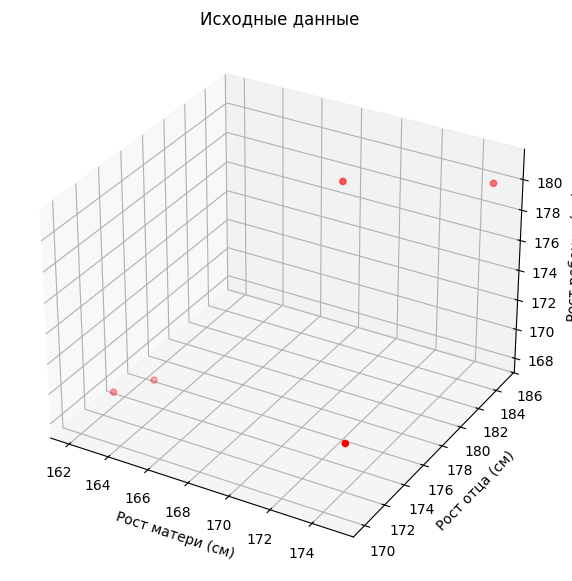

In [9]:
# Создание 3D-графика
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Нанесение исходных точек
ax.scatter(moms_height, dads_height, child_height, c='r', marker='o', label='Исходные данные')

# Добавление подписей к осям
ax.set_xlabel('Рост матери (см)')
ax.set_ylabel('Рост отца (см)')
ax.set_zlabel('Рост ребенка (см)')
ax.set_title('Исходные данные')
plt.show()

Задание 5.3. Теперь самое интересное: добавьте на этот же график плоскость регрессии, предсказанную моделью.

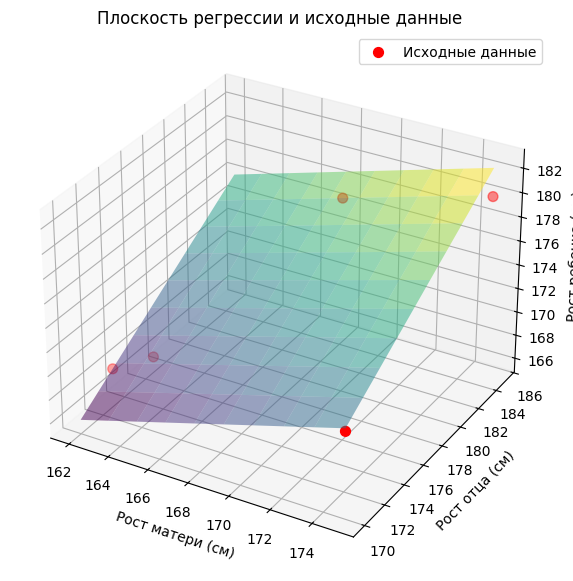

In [10]:
# Этот код объединяет предыдущий шаг и добавляет плоскость

# Создание 3D-графика
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Нанесение исходных точек
ax.scatter(moms_height, dads_height, child_height, c='r', marker='o', s=50, label='Исходные данные')

# Создание сетки для плоскости регрессии
mom_range = np.linspace(moms_height.min(), moms_height.max(), 10)
dad_range = np.linspace(dads_height.min(), dads_height.max(), 10)
mom_grid, dad_grid = np.meshgrid(mom_range, dad_range)

# Расчет предсказаний для каждой точки сетки
child_pred_surface = intercept + coefficients[0] * mom_grid + coefficients[1] * dad_grid

# Построение плоскости регрессии
ax.plot_surface(mom_grid, dad_grid, child_pred_surface, alpha=0.5, cmap='viridis')

# Настройка графика
ax.set_xlabel('Рост матери (см)')
ax.set_ylabel('Рост отца (см)')
ax.set_zlabel('Рост ребенка (см)')
ax.set_title('Плоскость регрессии и исходные данные')
plt.legend()
plt.show()